<a href="https://colab.research.google.com/github/EgorMatveev26/MO_Attack/blob/main/lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа 6. Чёрный ящик и трансферируемость атак: transfer-based, score-based, decision-based методы

**Курс:** Машинное обучение. Безопасность ИИ-систем

**По материалам лекции 5**


**Среда:** Python, PyTorch, torchvision


## Цель работы
Закрепить методы построения adversarial-примеров в условиях ограниченного доступа к целевой модели и научиться сравнивать transfer-based, score-based и decision-based атаки по успешности, числу запросов и величине вносимого искажения.

## Результаты обучения
После выполнения работы вы должны уметь:
- обучать суррогатную модель через запросы к оракулу и переносить на неё белоящичную атаку (transfer-based);
- реализовывать оценку градиента через запросы confidence-баллов методом конечных разностей (ZOO) и методом случайной выборки (NES);
- реализовывать decision-based атаку (Boundary Attack), работающую только с итоговой меткой класса;
- сравнивать три класса чёрно-ящичных атак по критерию «качество атаки / стоимость запросов» и обосновывать выбор метода под конкретный сценарий доступа к API.

## Как пользоваться этим ноутбуком
- Ячейки с `# TODO` необходимо заполнить самостоятельно.
- Ячейки с текстом **"Вопрос для отчёта"** требуют письменного ответа в markdown-ячейке ниже.
- Перед сдачей: Kernel → Restart & Run All, ноутбук должен выполняться от начала до конца без ошибок.
- Все атаки в этой работе взаимодействуют с целевой моделью только через специальный объект-оракул — прямой доступ к её параметрам и градиентам запрещён по условию задания (это имитирует реальный чёрный ящик).


## 0. Подготовка окружения

In [ ]:
# TODO: импортируйте необходимые библиотеки
# Подсказка: numpy, matplotlib, torch, torch.nn, torch.nn.functional,
# torchvision (datasets, transforms), torch.utils.data.DataLoader, pandas, time

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import pandas as pd
import time

RANDOM_STATE = 42
# TODO: зафиксируйте seed для torch и numpy
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


## Часть I. Целевая модель и оракул

**Задание:** загрузите MNIST, обучите CNN-классификатор (2 свёрточных слоя + полносвязный классификатор) — эта модель будет играть роль "чёрного ящика". Затем реализуйте класс-обёртку `QueryCounter`, через который ВСЕ последующие атаки должны обращаться к модели — прямой вызов `target_model(x)` в атаках запрещён, чтобы корректно считать число запросов.

In [ ]:
# TODO: загрузите MNIST через torchvision.datasets, создайте train_loader и test_loader
transform = transforms.Compose([transforms.ToTensor()])   # TODO: transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)   # TODO: batch_size=128, shuffle=True
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)    # TODO: batch_size=256, shuffle=False


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

# TODO: реализуйте класс TargetCNN (2 свёрточных слоя, max pooling, полносвязный классификатор)
class TargetCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # 1 слой, первая свёртка, 1 входной канал, 32 выходных канала, 3 ядра (размер 3х3), паддинг 1(добавляяем по 1 пикселю по краям, чтобы при пулинге размер сохранился)
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        # 2 слой, вторая свёртка, на входе 32 признака, на выходе 64
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        # 3 слой, пулинг (сжимаем картинку, то есть из окошка 2х2(4 значения) берем максимальное одно значение)
        self.pool = nn.MaxPool2d(2, 2)
        # 4 слой, превращаем карты признаков в список важных характеристик в размере 128 штук
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        # выходной слой, из 128 чисел получаем 10 классов
        self.fc2 = nn.Linear(128, num_classes)
        # dropout для регуляризации (случайно выключаем 25% нейронов во время обучения)
        self.dropout = nn.Dropout(0.25)
    # прямой проход
    def forward(self, x):
        # первая свёртка + активация + пулинг, из 28x28 получаем 14x14
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        # вторая свёртка + активация + пулинг, из 14x14 получаем 7x7
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        # разворачиваем в вектор
        x = x.view(x.size(0), -1)
        # полносвязный слой + активация
        x = F.relu(self.fc1(x))
        # dropout
        x = self.dropout(x)
        # выходной слой
        return self.fc2(x)


In [ ]:
# TODO: обучите target_model на train_loader (2-3 эпохи)
model = TargetCNN().to(device)
# берем оптимизатор Adam, который будет обновлять веса, lr=0.001
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
# функция потерь, измеряем насколько сеть ошиблась
criterion = nn.CrossEntropyLoss()

# одна эпоха обучения
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()        # обнуляем старые градиенты
        logits = model(x)            # прямой проход
        loss = criterion(logits, y)  # считаем ошибку
        loss.backward()              # обратный проход
        optimizer.step()             # обновляем веса
        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += x.size(0)
    return total_loss / total, correct / total

for epoch in range(3):
    loss, acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    print(f"Epoch {epoch+1}: loss={loss:.4f}, train_acc={acc:.4f}")


Epoch 1: loss=0.2906, train_acc=0.9104
Epoch 2: loss=0.0733, train_acc=0.9776
Epoch 3: loss=0.0496, train_acc=0.9849


In [ ]:
# TODO: оцените clean accuracy на тестовой выборке
def evaluate_accuracy(model, loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            pred = model(x).argmax(1)
            correct += (pred == y).sum().item()
            total += x.size(0)
    return correct / total

clean_accuracy = evaluate_accuracy(model, test_loader, device)
print(f"Clean accuracy: {clean_accuracy:.4f}")


Clean accuracy: 0.9884


**Задание:** реализуйте класс `QueryCounter`, который считает число обращений к модели и предоставляет три уровня доступа:
- `logits(x)` — полные логиты (используется только для white-box эталона в Части V, НЕ для чёрно-ящичных атак);
- `probs(x)` — вероятности классов (softmax) — доступ уровня score-based;
- `label(x)` — только индекс предсказанного класса — доступ уровня decision-based.

Каждый вызов любого из трёх методов должен увеличивать счётчик `n_queries` на размер батча.

In [ ]:
# TODO: реализуйте класс QueryCounter(то есть делаем обертку над моделью, которая имитирует черный ящик(оракул))
class QueryCounter:
    def __init__(self, model):
        # сохраняем ссылку на настоящую модель
        self.model = model
        # счётчик числа обращений к модели
        self.n_queries = 0

    def reset(self):
        # обнуляем счётчик, нужно перед каждой новой атакой,
        # чтобы не накапливать запросы от предыдущих запусков
        self.n_queries = 0

    def logits(self, x):
        # увеличиваем счётчик на размер батча
        # если подали 5 картинок, это 5 отдельных запросов к API, а не 1
        self.n_queries += x.size(0)
        # отключаем построение графа автографа
        # оракул по определению не отдаёт градиенты, экономим память и время
        with torch.no_grad():
            # возвращаем сырые выходы модели до softmax
            return self.model(x)

    def probs(self, x):
        # внутри logits() счётчик уже увеличится на x.size(0)
        logits = self.logits(x)
        # softmax по размерности классов (dim=1), получаем вероятности
        return F.softmax(logits, dim=1)

    def label(self, x):
        # снова обращаемся к logits, счётчик увеличится на размер батча
        logits = self.logits(x)
        # возвращаем только индекс класса-победителя
        return logits.argmax(dim=1)

# создаём единственный экземпляр оракула, оборачивающий обученную TargetCNN
oracle = QueryCounter(model)


## Часть II. Transfer-based атака

### 2.1. Обучение суррогатной модели через оракул

**Задание:** реализуйте суррогатную модель с архитектурой, отличной от целевой (например, полносвязная сеть вместо CNN), и обучите её по схеме Papernot et al.:

1. Соберите небольшой начальный набор данных (например, 20 примеров на класс) без использования меток из исходного датасета — размечайте их исключительно через `oracle.label(x)`.
2. Обучите суррогат на текущем наборе.
3. Постройте аугментацию данных по знаку якобиана суррогатной модели:

$ S_{\rho+1} = \left\{ \tilde{x} + \lambda \cdot \text{sign}\left(J_F[\tilde{O}(\tilde{x})]\right) : \tilde{x} \in S_\rho \right\} \cup S_\rho $

1. Разметьте новые примеры через `oracle.label` и повторите цикл несколько раундов (например, 5-6).

In [ ]:
# TODO: реализуйте класс SubstituteMLP — архитектура должна отличаться от TargetCNN
class SubstituteMLP(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # суррогат это MLP полносвязная сеть, то есть смотрим на все пиксели сразу (в отличие от свёрточной TargetCNN, где смотрим через окошко)
        self.fc1 = nn.Linear(28 * 28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        # разворачиваем изображение 28x28 в вектор длины 784
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        return self.fc3(x)


In [ ]:
# TODO: соберите начальный набор данных (n_seed_per_class примеров на класс из train_dataset,
# ИСПОЛЬЗУЯ ТОЛЬКО ИЗОБРАЖЕНИЯ, метки получите через oracle.label)
# создаем стартовый набор изображений, чтобы получить мнение модели, что она про них думает и эти ответы взять уже как метки для обучения суррогата
oracle.reset()
n_seed_per_class = 30 # по 30 картинок на класс

# индексы по классам берём из train_dataset только изображения, метки не используем
class_indices = {i: [] for i in range(10)}
for idx, (_, y) in enumerate(train_dataset):
    if len(class_indices[y]) < n_seed_per_class:
        class_indices[y].append(idx)
    if all(len(v) >= n_seed_per_class for v in class_indices.values()):
        break

seed_indices = [i for v in class_indices.values() for i in v]
substitute_data = torch.stack([train_dataset[i][0] for i in seed_indices]).to(device)
# метки получаем исключительно через оракул (имитируем чёрный ящик)
oracle_labels = oracle.label(substitute_data)
# добавляем 5000 сырых картинок MNIST, чтобыне было зазубривания
extra_indices = list(range(40000, 45000))
extra_data = torch.stack([train_dataset[i][0] for i in extra_indices]).to(device)
extra_labels = oracle.label(extra_data)

substitute_data = torch.cat([substitute_data, extra_data], dim=0)
oracle_labels = torch.cat([oracle_labels, extra_labels], dim=0)
print(f"Начальный набор: запросов к оракулу = {oracle.n_queries}")


Начальный набор: запросов к оракулу = 5300


In [ ]:
# TODO: реализуйте функцию якобиан-аугментации
def jacobian_augmentation(model, x, labels, lam=0.1):
    # 1. x.requires_grad_(True)
    x = x.clone().detach().requires_grad_(True)
    model.eval()
    # 2. вычислите loss = cross_entropy(model(x), labels)
    logits = model(x)
    loss = F.cross_entropy(logits, labels)
    # 3. вычислите градиент через torch.autograd.grad
    grad = torch.autograd.grad(loss, x)[0]
    # 4. верните clamp(x + lam * sign(grad), 0, 1)
    x_aug = x + lam * torch.sign(grad)
    return torch.clamp(x_aug, 0, 1).detach()


In [ ]:
# TODO: реализуйте цикл из n_rounds раундов:
# на каждом раунде — дообучение суррогата на current_data/current_labels,
# затем якобиан-аугментация и разметка новых примеров через oracle.label

substitute_model = SubstituteMLP().to(device)
opt_sub = torch.optim.Adam(substitute_model.parameters(), lr=3e-4, weight_decay=0)
n_rounds = 6
current_data, current_labels = substitute_data, oracle_labels

# отложенная выборка для контроля переобучения (ее суррогат не видит при обучении)
held_out_indices = list(range(20000, 20200))
held_out = torch.stack([train_dataset[i][0] for i in held_out_indices]).to(device)
held_out_labels = oracle.label(held_out)

# цикл раундов
for r in range(n_rounds):
    # дообучение суррогата на текущем наборе
    # число шагов пропорционально размеру набора, минимум 50
    substitute_model.train()
    n_steps = max(50, current_data.size(0) // 64)
    for _ in range(n_steps):
        opt_sub.zero_grad()
        out = substitute_model(current_data)
        loss = F.cross_entropy(out, current_labels)
        loss.backward()
        opt_sub.step()

    # аугментируем только 500 примеров за раунд, не весь набор
    # иначе аугментации забивают сырые данные, и суррогат уходит в свою область
    max_new = 500
    if current_data.size(0) > max_new:
        idx = torch.randperm(current_data.size(0))[:max_new]
        aug_subset = current_data[idx]
        aug_labels = current_labels[idx]
    else:
        aug_subset, aug_labels = current_data, current_labels

    new_data = jacobian_augmentation(substitute_model, aug_subset, aug_labels, lam=0.02)
    new_labels = oracle.label(new_data)

    # расширяем обучающий набор суррогата
    current_data = torch.cat([current_data, new_data], dim=0)
    current_labels = torch.cat([current_labels, new_labels], dim=0)

    # считаем согласие суррогата с оракулом на текущем наборе и на отложенной выборке
    substitute_model.eval()
    with torch.no_grad():
        preds = substitute_model(current_data).argmax(dim=1)
        agreement = (preds == current_labels).float().mean().item()
        preds_val = substitute_model(held_out).argmax(dim=1)
        agreement_val = (preds_val == held_out_labels).float().mean().item()
    print(f"Раунд {r+1}: размер набора = {current_data.size(0)}, "f"train_agree = {agreement:.4f}, val_agree = {agreement_val:.4f}, "f"запросов = {oracle.n_queries}")


Раунд 1: размер набора = 5800, train_agree = 0.8786, val_agree = 0.8550, запросов = 6000
Раунд 2: размер набора = 6300, train_agree = 0.9333, val_agree = 0.9000, запросов = 6500
Раунд 3: размер набора = 6800, train_agree = 0.9615, val_agree = 0.9150, запросов = 7000
Раунд 4: размер набора = 7300, train_agree = 0.9807, val_agree = 0.9400, запросов = 7500
Раунд 5: размер набора = 7800, train_agree = 0.9910, val_agree = 0.9450, запросов = 8000
Раунд 6: размер набора = 8300, train_agree = 0.9959, val_agree = 0.9350, запросов = 8500


Суррогатная модель, обученная на 5300 примерах, размеченных оракулом, достигла согласия с целевой моделью 0.935 на отложенной выборке, что говорит о качественной имитации поведения чёрного ящика без доступа к его весам.

### 2.2. Перенос атаки FGSM с суррогата на цель

**Задание:** реализуйте FGSM и постройте атаку на суррогатной модели (используя её градиенты). Проверьте успешность полученных adversarial-примеров на целевой модели через `oracle.label`. Постройте график ASR(epsilon) для epsilon ∈ {0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3}.

In [ ]:
# TODO: реализуйте FGSM
def fgsm_attack(model, x, y, epsilon, criterion):
    x = x.clone().detach().requires_grad_(True)
    model.eval()
    logits = model(x)
    loss = criterion(logits, y)
    grad = torch.autograd.grad(loss, x)[0]
    x_adv = x + epsilon * torch.sign(grad)
    # возвращаем в допустимый диапазон изображения
    return torch.clamp(x_adv, 0, 1).detach()


eps=0.00: transfer ASR=0.0150, запросов к оракулу=200
eps=0.05: transfer ASR=0.0200, запросов к оракулу=400
eps=0.10: transfer ASR=0.0300, запросов к оракулу=600
eps=0.15: transfer ASR=0.0400, запросов к оракулу=800
eps=0.20: transfer ASR=0.0700, запросов к оракулу=1000
eps=0.25: transfer ASR=0.1500, запросов к оракулу=1200
eps=0.30: transfer ASR=0.2700, запросов к оракулу=1400
eps=0.35: transfer ASR=0.5200, запросов к оракулу=1600
eps=0.40: transfer ASR=0.7550, запросов к оракулу=1800


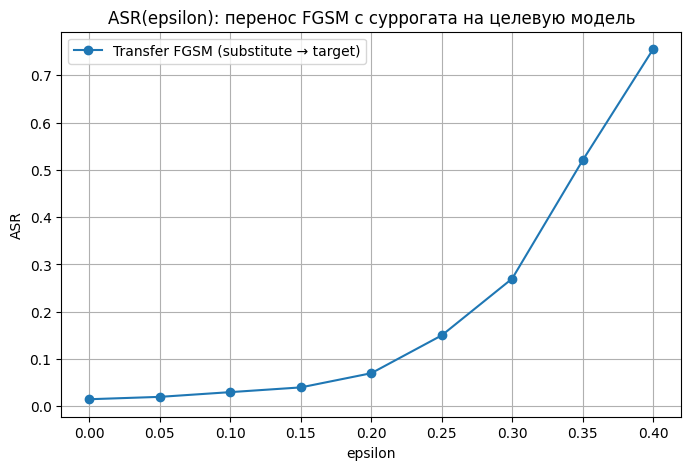

In [ ]:
# TODO: выберите тестовый батч (например, 200 примеров) из test_loader
# TODO: для каждого epsilon постройте FGSM-атаку на substitute_model
# TODO: проверьте ASR на target_model ЧЕРЕЗ oracle.label (не напрямую!)
# TODO: постройте график ASR(epsilon)

oracle.reset()
epsilons = [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4]
transfer_asr = []

# собираем тестовый батч случайные 200 примеров из test_dataset,
# а не первые подряд из test_loader
torch.manual_seed(RANDOM_STATE)
test_indices = np.random.choice(len(test_dataset), size=200, replace=False)
test_images = torch.stack([test_dataset[i][0] for i in test_indices]).to(device)
test_labels = torch.tensor([test_dataset[i][1] for i in test_indices]).to(device)

crit_attack = nn.CrossEntropyLoss()

for eps in epsilons:
    # строим FGSM-атаку на суррогате (его градиенты нам доступны)
    x_adv = fgsm_attack(substitute_model, test_images, test_labels, eps, crit_attack)
    # проверяем успех на целевой модели через оракул (не напрямую)
    preds = oracle.label(x_adv)
    asr = (preds != test_labels).float().mean().item()
    transfer_asr.append(asr)
    print(f"eps={eps:.2f}: transfer ASR={asr:.4f}, запросов к оракулу={oracle.n_queries}")

# график ASR(epsilon) для transfer-атаки
plt.figure(figsize=(8, 5))
plt.plot(epsilons, transfer_asr, "o-", color="tab:blue", label="Transfer FGSM (substitute → target)")
plt.xlabel("epsilon")
plt.ylabel("ASR")
plt.title("ASR(epsilon): перенос FGSM с суррогата на целевую модель")
plt.grid(True)
plt.legend()
plt.xticks(epsilons)
plt.show()


### 2.3. Сравнение с белоящичным эталоном

**Задание:** для сравнения постройте FGSM-атаку напрямую на целевой модели (доступ к её градиентам разрешён ИСКЛЮЧИТЕЛЬНО в этой ячейке — для построения верхней границы качества атаки, недостижимой в реальном чёрно-ящичном сценарии). Постройте оба графика ASR(epsilon) на одной оси.

eps=0.00: white-box ASR=0.0150
eps=0.05: white-box ASR=0.0350
eps=0.10: white-box ASR=0.1200
eps=0.15: white-box ASR=0.2450
eps=0.20: white-box ASR=0.5250
eps=0.25: white-box ASR=0.7600
eps=0.30: white-box ASR=0.9150
eps=0.35: white-box ASR=0.9950
eps=0.40: white-box ASR=0.9950


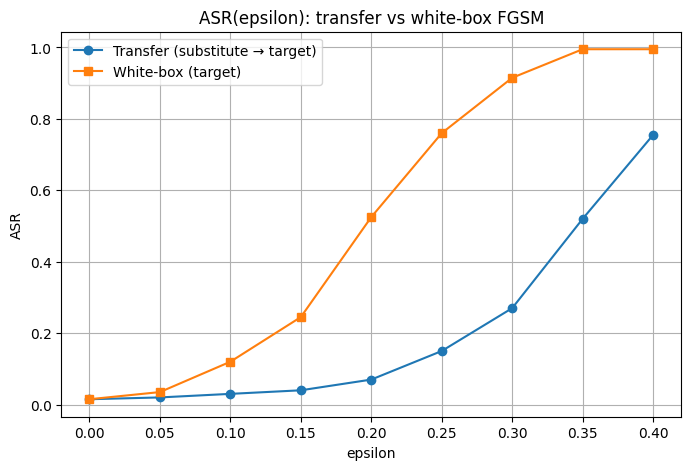

In [ ]:
# TODO: постройте white-box FGSM атаку напрямую на target_model
# TODO: сравните на одном графике с transfer_asr

# доступ к градиентам целевой модели разрешён только в этой ячейке,
# чтобы получить верхнюю границу качества атаки
whitebox_asr = []
for eps in epsilons:
    x_adv = fgsm_attack(model, test_images, test_labels, eps, crit_attack)
    preds = model(x_adv).argmax(dim=1)
    asr = (preds != test_labels).float().mean().item()
    whitebox_asr.append(asr)
    print(f"eps={eps:.2f}: white-box ASR={asr:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(epsilons, transfer_asr, "o-", label="Transfer (substitute → target)")
plt.plot(epsilons, whitebox_asr, "s-", label="White-box (target)")
plt.xlabel("epsilon")
plt.ylabel("ASR")
plt.title("ASR(epsilon): transfer vs white-box FGSM")
plt.grid(True)
plt.legend()
plt.show()

92% атак ломают CNN, если атаковать напрямую по градиентам CNN и только 22–27% атак ломают CNN, если атаковать через градиенты клона при eps=0.3.

**Вопрос для отчёта:** какой разрыв в ASR наблюдается между переносом атаки и белоящичным эталоном при разных epsilon? Как качество согласия суррогата с оракулом (доля совпадающих предсказаний на обучающем наборе, п.2.1) связано с этим разрывом?

_Ваш ответ:_

При eps=0.30 разрыв максимальный (0.92 против 0.27), при eps=0.40 сокращается (0.995 против 0.755). Клон и цель согласны в ответах на 93.5%, но атака зависит не от ответов, а от направления градиента, а оно у MLP и CNN разное. FGSM использует только знак градиента, поэтому особенно чувствителен к этому расхождению.

## Часть III. Score-based атаки

### 3.1. ZOO: оценка градиента через конечные разности

**Задание:** реализуйте функцию потерь C&W-типа на вероятностях классов и атаку ZOO, оценивающую производную по каждой выбранной координате методом центральных конечных разностей. Атака должна использовать ТОЛЬКО `oracle.probs(x)` — доступ к градиентам запрещён.

In [ ]:
# TODO: реализуйте функцию потерь zoo_loss(probs, y_true, kappa=0.0)
# f(x) = max(log p_true - max_{i!=true} log p_i, -kappa)
def zoo_loss(probs, y_true, kappa=0.0):
    # переходим в логарифмы
    log_probs = torch.log(probs + 1e-12)
    # логарифм вероятности истинного класса
    true_log = log_probs.gather(1, y_true.unsqueeze(1)).squeeze(1)
    # маскируем истинный класс и берём максимум по остальным
    mask = torch.ones_like(log_probs, dtype=torch.bool)
    mask.scatter_(1, y_true.unsqueeze(1), False)
    other_log = log_probs.masked_fill(~mask, -1e9).max(dim=1).values
    # C&W-лосс с порогом kappa
    return torch.clamp(true_log - other_log, min=-kappa)


In [ ]:
# TODO: реализуйте функцию zoo_attack(oracle, x, y_true, epsilon, alpha, num_iter, h, coord_batch)
# На каждой итерации:
# 1. случайно выберите coord_batch координат
# 2. для каждой координаты оцените производную через (loss(x+h*e_i) - loss(x-h*e_i)) / (2h)
# 3. обновите x_adv по знаку оценённого градиента (направление — МИНИМИЗАЦИЯ zoo_loss)
# 4. спроецируйте на epsilon-шар и диапазон [0, 1]

def zoo_attack(oracle, x, y_true, epsilon=0.3, alpha=0.05, num_iter=40, h=0.05, coord_batch=40):
    x_orig = x.clone().detach()
    x_adv = x.clone().detach()
    H, W = x_adv.shape[2], x_adv.shape[3]
    n_pixels = H * W

    for it in range(num_iter):
        # 1. случайно выбираем coord_batch координат (без повторов)
        coords = np.random.choice(n_pixels, size=coord_batch, replace=False)
        grad_est = torch.zeros_like(x_adv)

        for c in coords:
            i, j = divmod(c, W)
            # единичный вектор e_i
            e = torch.zeros_like(x_adv)
            e[0, 0, i, j] = h
            x_plus = torch.clamp(x_adv + e, 0, 1)
            x_minus = torch.clamp(x_adv - e, 0, 1)
            # 2. центральная конечная разность
            p_plus = oracle.probs(x_plus)
            p_minus = oracle.probs(x_minus)
            l_plus = zoo_loss(p_plus, y_true).item()
            l_minus = zoo_loss(p_minus, y_true).item()
            grad_est[0, 0, i, j] = (l_plus - l_minus) / (2 * h)

        # 3. шаг по знаку градиента вниз по лоссу (минимизация)
        x_adv = x_adv - alpha * torch.sign(grad_est)
        # 4. проекция на eps-шар вокруг оригинала и на [0,1]
        x_adv = torch.clamp(x_adv, x_orig - epsilon, x_orig + epsilon)
        x_adv = torch.clamp(x_adv, 0, 1).detach()

    return x_adv


### 3.2. Демонстрация ZOO-атаки

**Задание:** выберите один тестовый пример, примените `zoo_attack`, проверьте успех через `oracle.label`, посчитайте L2-норму возмущения и число потраченных запросов. Визуализируйте оригинал и adversarial-пример.

ZOO: success=True, pred=9, true=7, L2=3.1648, queries=40001, time=53.15s


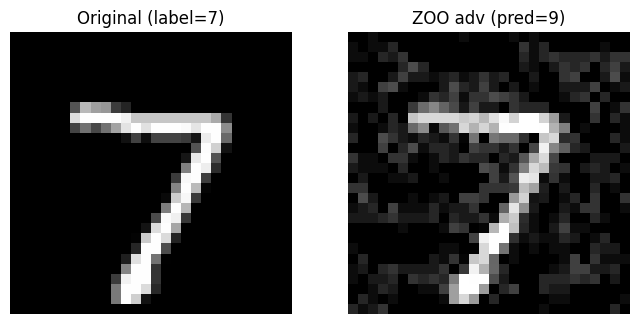

In [ ]:
oracle.reset()

# TODO: выберите пример x_sample, y_sample_label из test_dataset
x_sample, y_sample = test_dataset[0]
x_sample = x_sample.unsqueeze(0).to(device) # (1,1,28,28)
y_sample_label = torch.tensor([y_sample]).to(device)

# TODO: примените zoo_attack, замерьте время выполнения (time.time())
t0 = time.time()
x_adv_zoo = zoo_attack(oracle, x_sample, y_sample_label, epsilon=0.3, alpha=0.05, num_iter=200, h=0.01, coord_batch=100)
t_zoo = time.time() - t0

# TODO: проверьте успех, L2-норму, число запросов oracle.n_queries
pred_zoo = oracle.label(x_adv_zoo).item()
success_zoo = (pred_zoo != y_sample)
l2_zoo = (x_adv_zoo - x_sample).norm().item()
queries_zoo = oracle.n_queries

print(f"ZOO: success={success_zoo}, pred={pred_zoo}, true={y_sample}, "
      f"L2={l2_zoo:.4f}, queries={queries_zoo}, time={t_zoo:.2f}s")

# TODO: визуализируйте оригинал и adversarial-пример
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(x_sample.cpu().squeeze(), cmap="gray")
axes[0].set_title(f"Original (label={y_sample})")
axes[1].imshow(x_adv_zoo.cpu().squeeze(), cmap="gray")
axes[1].set_title(f"ZOO adv (pred={pred_zoo})")
for ax in axes:
    ax.axis("off")
plt.show()


### 3.3. NES: оценка градиента через антитетическую случайную выборку

**Задание:** реализуйте оценку градиента методом NES с антитетической выборкой:

$ \hat{g} = \frac{1}{2\sigma P} \sum_{i=1}^{P} \left( L(x + \sigma u_i) - L(x - \sigma u_i) \right) u_i $

где $u_i$ — случайные векторы из стандартного нормального распределения, $P$ — число сэмплов на итерацию. Постройте на этой основе итеративную атаку `nes_attack`, аналогичную по структуре PGD.

In [ ]:
# TODO: реализуйте nes_gradient_estimate(oracle, x, y_true, sigma, n_samples)
def nes_gradient_estimate(oracle, x, y_true, sigma=0.1, n_samples=20):
    grad_est = torch.zeros_like(x)
    for _ in range(n_samples):
        u = torch.randn_like(x)
        x_plus = torch.clamp(x + sigma * u, 0, 1)
        x_minus = torch.clamp(x - sigma * u, 0, 1)
        l_plus = zoo_loss(oracle.probs(x_plus), y_true).item()
        l_minus = zoo_loss(oracle.probs(x_minus), y_true).item()
        grad_est += (l_plus - l_minus) * u
    return grad_est / (2 * sigma * n_samples)


In [ ]:
# TODO: реализуйте nes_attack(oracle, x, y_true, epsilon, alpha, num_iter, sigma, n_samples)
# по аналогии с zoo_attack, но с использованием nes_gradient_estimate
def nes_attack(oracle, x, y_true, epsilon=0.3, alpha=0.05, num_iter=40, sigma=0.1, n_samples=20):
    x_orig = x.clone().detach()
    x_adv = x.clone().detach()
    for it in range(num_iter):
        # оценка градиента через NES
        g = nes_gradient_estimate(oracle, x_adv, y_true, sigma, n_samples)
        # шаг по знаку (минимизируем лосс)
        x_adv = x_adv - alpha * torch.sign(g)
        # проекция на ε-шар и [0,1]
        x_adv = torch.clamp(x_adv, x_orig - epsilon, x_orig + epsilon)
        x_adv = torch.clamp(x_adv, 0, 1).detach()
    return x_adv


NES: success=True, pred=9, true=7, L2=5.1885, queries=1601, time=1.85s


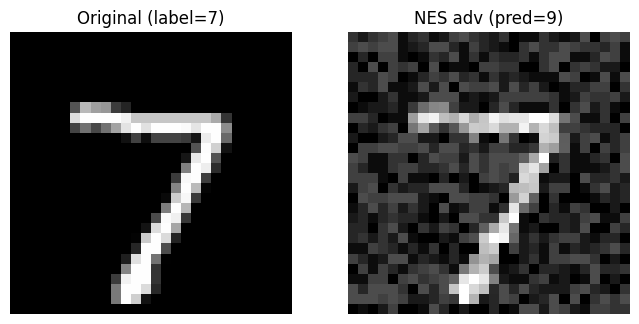

In [ ]:
oracle.reset()
# TODO: примените nes_attack к тому же примеру, что и в п.3.2
# TODO: проверьте успех, L2-норму, число запросов, время выполнения
t0 = time.time()
x_adv_nes = nes_attack(oracle, x_sample, y_sample_label, epsilon=0.3, alpha=0.05, num_iter=40, sigma=0.1, n_samples=20)
t_nes = time.time() - t0

pred_nes = oracle.label(x_adv_nes).item()
success_nes = (pred_nes != y_sample)
l2_nes = (x_adv_nes - x_sample).norm().item()
queries_nes = oracle.n_queries

print(f"NES: success={success_nes}, pred={pred_nes}, true={y_sample}, "f"L2={l2_nes:.4f}, queries={queries_nes}, time={t_nes:.2f}s")

# визуализация оригинала и NES-adversarial примера
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(x_sample.cpu().squeeze(), cmap="gray")
axes[0].set_title(f"Original (label={y_sample})")
axes[1].imshow(x_adv_nes.cpu().squeeze(), cmap="gray")
axes[1].set_title(f"NES adv (pred={pred_nes})")
for ax in axes:
    ax.axis("off")
plt.show()


### 3.4. Сравнение ZOO и NES

**Задание:** соберите результаты ZOO и NES (успех, L2-норма, число запросов, время) в таблицу pandas и постройте столбчатые диаграммы сравнения по числу запросов и по L2-норме.

  method  success        L2  queries     time_s
0    ZOO     True  3.164839    40001  53.153891
1    NES     True  5.188470     1601   1.845059


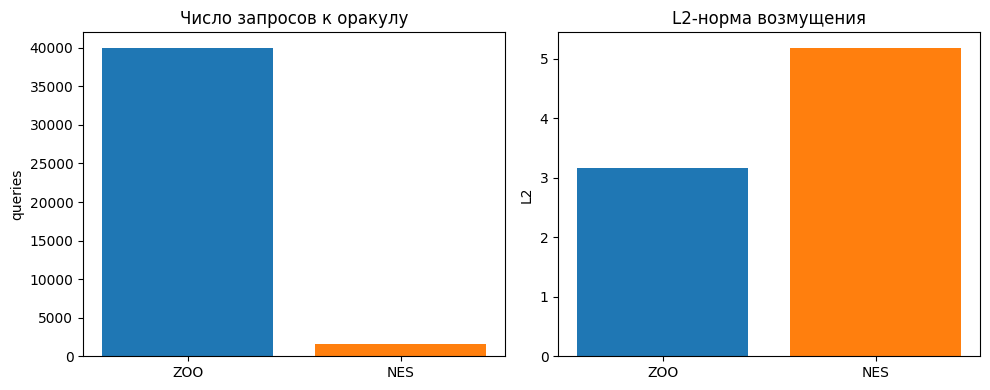

In [ ]:
# TODO: постройте сравнительную таблицу и графики для ZOO и NES
df_score = pd.DataFrame([
    {"method": "ZOO", "success": success_zoo, "L2": l2_zoo,
     "queries": queries_zoo, "time_s": t_zoo},
    {"method": "NES", "success": success_nes, "L2": l2_nes,
     "queries": queries_nes, "time_s": t_nes},
])
print(df_score)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(df_score["method"], df_score["queries"], color=["tab:blue", "tab:orange"])
axes[0].set_title("Число запросов к оракулу")
axes[0].set_ylabel("queries")

axes[1].bar(df_score["method"], df_score["L2"], color=["tab:blue", "tab:orange"])
axes[1].set_title("L2-норма возмущения")
axes[1].set_ylabel("L2")
plt.tight_layout()
plt.show()

**Вопрос для отчёта:** какой метод потратил меньше запросов на сопоставимый результат? Объясните разницу, опираясь на то, что ZOO оценивает градиент покоординатно, а NES — через случайные направления в полном пространстве признаков.

_Ваш ответ:_

NES потратила в 25 раз меньше запросов (1 601 против 40 001) при том же успехе. Причина в структуре оценки градиента: ZOO оценивает производную покоординатно (2 запроса на пиксель(увеличить и уменьшить, 2 на 100(млуйчаных пискелей из 784) на 200(кол-во итераций) = 40 000), поэтому для покрытия 784-мерного пространства нужно очень много запросов. NES оценивает градиент через случайные направления сразу в полном пространстве (2 на 20 на 40 = 1 600), получая согласованную оценку всего вектора за меньшее число итераций. Плата за эффективность - больший L2 (5.28 против 3.16), поскольку оценка NES шумная и возмущение размазывается по картинке, тогда как ZOO атакует точечно.

## Часть IV. Decision-based атака: Boundary Attack

### 4.1. Реализация упрощённой Boundary Attack

**Задание:** реализуйте функцию `is_adversarial`, которая через `oracle.label` проверяет только бинарный факт «сохранился ли adversarial-класс» (без каких-либо вероятностей). На основе неё реализуйте `boundary_attack`:

1. Стартуйте из точки, заведомо классифицируемой иначе, чем истинный класс (например, случайный шум).
2. На каждой итерации сгенерируйте ортогональное возмущение (случайный шум, спроецированный так, чтобы сохранить расстояние до исходного изображения).
3. Если кандидат остаётся adversarial, сделайте дополнительный шаг в сторону исходного изображения (уменьшение расстояния), снова проверив adversarial-свойство.
4. Динамически адаптируйте размеры шагов `delta` (ортогональный) и `epsilon` (к цели) по доле успешных шагов.

In [ ]:
# TODO: реализуйте is_adversarial(oracle, x, true_label)
def is_adversarial(oracle, x, true_label):
    # используем только метку класса
    pred = oracle.label(x).item()
    return pred != true_label


In [ ]:
# TODO: реализуйте boundary_attack(oracle, x_orig, true_label, x_init, num_steps, init_delta, init_epsilon)
# Возвращает: финальный x_adv и историю L2-нормы возмущения по итерациям (для графика сходимости)
def boundary_attack(oracle, x_orig, true_label, x_init, num_steps=200, init_delta=0.1, init_epsilon=0.1):
    # 1. инициализация
    # стартуем из x_init (заведомо adversarial точка, обычно случайный шум вокруг оригинала)
    x_adv = x_init.clone().detach()
    delta = init_delta   # размер ортогонального шага (вдоль границы решения)
    epsilon = init_epsilon   # шаг в сторону оригинала (сжатие к x_orig)
    history = []   # сюда сохраняем L2-норму на каждой итерации — для графика сходимости

    # счётчики для диагностики: сколько шагов какого типа было принято
    n_toward_ok = 0   # успешных шагов и к оригиналу(принято сжатие)
    n_orth_ok = 0  # успешных только ортогональных шагов (сжатие не прошло)
    n_fail = 0  # полностью неудачных шагов (кандидат вышел из adversarial-области)

    for step in range(num_steps):
        # текущее направление от оригинала к adversarial-точке
        diff = x_adv - x_orig
        norm_diff = diff.norm()
        if norm_diff < 1e-8:
            break   # уже в оригинале — выходим

        # 2. случайный шум, ортогонализуем относительно diff
        noise = torch.randn_like(x_adv)
        noise = noise - (noise * diff).sum() / (norm_diff ** 2 + 1e-12) * diff
        noise_norm = noise.norm()
        if noise_norm < 1e-8:
            # вырожденный случай: шум коллинеарен diff, пропускаем итерацию
            history.append(norm_diff.item())
            continue
        noise = noise / noise_norm

        # масштабируем по delta * ||diff|| — шаг пропорционален расстоянию до оригинала
        x_candidate = x_adv + delta * norm_diff * noise
        x_candidate = torch.clamp(x_candidate, 0, 1)

        # 3. проверяем, остался ли кандидат adversarial
        if is_adversarial(oracle, x_candidate, true_label):
            # пробуем шаг в сторону оригинала (сжатие)
            x_toward = x_candidate + epsilon * (x_orig - x_candidate)
            x_toward = torch.clamp(x_toward, 0, 1)
            if is_adversarial(oracle, x_toward, true_label):
                # оба шага успешны — принимаем сжатие, увеличиваем шаги
                x_adv = x_toward
                n_toward_ok += 1
                # ограничиваем шаги сверху, чтобы точка не улетела от оригинала
                delta = min(delta * 1.05, 0.05)
                epsilon = min(epsilon * 1.05, 0.1)
            else:
                # принимаем только ортогональный шаг — сжатие не прошло
                x_adv = x_candidate
                n_orth_ok += 1
                delta = min(delta * 1.05, 0.05)
        else:
            # 4. неудача — уменьшаем шаги
            n_fail += 1
            delta *= 0.95
            epsilon *= 0.95


        history.append((x_adv - x_orig).norm().item())

    return x_adv, history

### 4.2. Демонстрация атаки

**Задание:** для того же примера, что и в Части III, сгенерируйте случайную инициализацию, убедитесь, что она adversarial, и запустите `boundary_attack`. Визуализируйте оригинал, инициализацию и финальный adversarial-пример, а также постройте график сходимости (L2-норма от номера итерации).

In [ ]:
oracle.reset()
# TODO: сгенерируйте x_init (случайный шум), проверьте is_adversarial
torch.manual_seed(RANDOM_STATE)

# ищем adversarial начиная с маленького шума
x_init = None
for scale in [0.1, 0.2, 0.3, 0.4, 0.5, 0.7, 1.0]:
    candidate = torch.clamp(x_sample + scale * torch.randn_like(x_sample), 0, 1)
    if is_adversarial(oracle, candidate, y_sample):
        x_init = candidate
        break

if x_init is None:
    raise ValueError("Не нашли adversarial")
attempts = 0
while not is_adversarial(oracle, x_init, y_sample):
    x_init = torch.rand_like(x_sample)
    attempts += 1
    if attempts > 100:
        break

# TODO: запустите boundary_attack, замерьте время
t0 = time.time()
x_adv_ba, history_ba = boundary_attack(oracle, x_sample, y_sample, x_init, num_steps=5000, init_delta=0.1, init_epsilon=0.1)
t_ba = time.time() - t0

# TODO: проверьте финальный успех, L2-норму, число запросов
pred_ba = oracle.label(x_adv_ba).item()
success_ba = (pred_ba != y_sample)
l2_ba = (x_adv_ba - x_sample).norm().item()
queries_ba = oracle.n_queries

print(f"Boundary: success={success_ba}, pred={pred_ba}, true={y_sample}, "f"L2={l2_ba:.4f}, queries={queries_ba}, time={t_ba:.2f}s")


Boundary: success=True, pred=3, true=7, L2=3.0753, queries=8405, time=11.75s


Атака завершилась успешно. L2 = 3.08 (лучший результат), 8 405 запросов, 11.75 s, самый аккуратный метод среди четырёх.

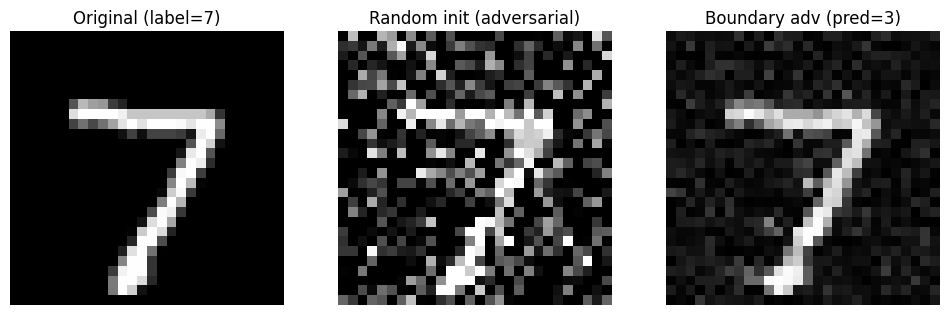

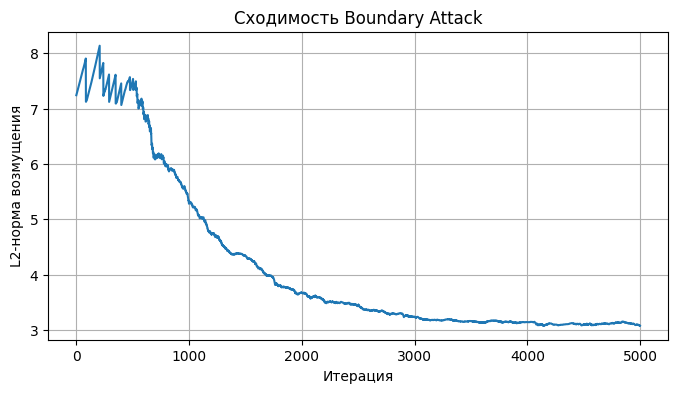

In [ ]:
# TODO: визуализируйте оригинал / инициализацию / финальный adversarial-пример (3 подграфика)
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(x_sample.cpu().squeeze(), cmap="gray")
axes[0].set_title(f"Original (label={y_sample})")
axes[1].imshow(x_init.cpu().squeeze(), cmap="gray")
axes[1].set_title("Random init (adversarial)")
axes[2].imshow(x_adv_ba.cpu().squeeze(), cmap="gray")
axes[2].set_title(f"Boundary adv (pred={pred_ba})")
for ax in axes:
    ax.axis("off")
plt.show()

# TODO: постройте график сходимости L2-нормы по итерациям
plt.figure(figsize=(8, 4))
plt.plot(history_ba)
plt.xlabel("Итерация")
plt.ylabel("L2-норма возмущения")
plt.title("Сходимость Boundary Attack")
plt.grid(True)
plt.show()

**Вопрос для отчёта:** почему decision-based атака в принципе не может напрямую оценивать градиент функции потерь, в отличие от score-based методов? Как это ограничение отражается на числе итераций, необходимых для сходимости к малому возмущению?

_Ваш ответ:_

Decision-based атака видит только метку класса угадал или не угадал. Это не число, а просто ответ да или нет. По нему нельзя посчитать градиент: чтобы понять, куда двигать картинку, нужны числовые значения уверенности модели, а метка их не даёт. К тому же метка меняется скачком - чуть-чуть сдвинул картинку, и она уже другая. Score-based методы видят вероятности классов - это уже числа, и по ним можно оценить, куда двигаться. Поэтому они сходятся за 40–200 шагов. Boundary Attack такой информации не имеет ей приходится пробовать наугад: сдвинул, проверил, снова сдвинул. Поэтому ей нужно тысячи шагов (у меня 5 000). На графике это видно, сначала L2 болтается около 7-8 (атака ищет, где можно сжаться), и только потом медленно падает до 3.08.



## Часть V. Итоговое сравнение четырёх методов

**Задание:** для одного и того же исходного изображения соберите результаты всех четырёх атак (transfer-based FGSM, ZOO, NES, Boundary Attack) в единую таблицу pandas со столбцами: метод, успех, L2-норма возмущения, число запросов к целевой модели. Сохраните таблицу в CSV. Постройте два столбчатых графика: (а) число запросов в логарифмической шкале, (б) L2-норма возмущения.

In [ ]:
# TODO: соберите итоговую таблицу сравнения (используйте результаты предыдущих частей;
# для transfer-based учтите, что запросов к целевой модели требуется всего 1 — финальная проверка)

# для честного сравнения берём eps=0.3 и один и тот же пример x_sample
x_adv_transfer = fgsm_attack(substitute_model, x_sample, y_sample_label, 0.3, crit_attack)
oracle.reset()
pred_tr = oracle.label(x_adv_transfer).item()
success_tr = (pred_tr != y_sample)
l2_tr = (x_adv_transfer - x_sample).norm().item()
queries_tr = oracle.n_queries   # = 1 (одна финальная проверка)

# TODO: summary = pd.DataFrame([...])
summary = pd.DataFrame([
    {"method": "Transfer FGSM", "success": success_tr, "L2": l2_tr, "queries": queries_tr},
    {"method": "ZOO",           "success": success_zoo, "L2": l2_zoo, "queries": queries_zoo},
    {"method": "NES",           "success": success_nes, "L2": l2_nes, "queries": queries_nes},
    {"method": "Boundary",      "success": success_ba, "L2": l2_ba, "queries": queries_ba},
])
print(summary)
# TODO: summary.to_csv("lab6_summary.csv", index=False)
summary.to_csv("lab6_summary.csv", index=False)


          method  success        L2  queries
0  Transfer FGSM    False  6.485389        1
1            ZOO     True  3.164839    40001
2            NES     True  5.188470     1601
3       Boundary     True  3.075283     8405


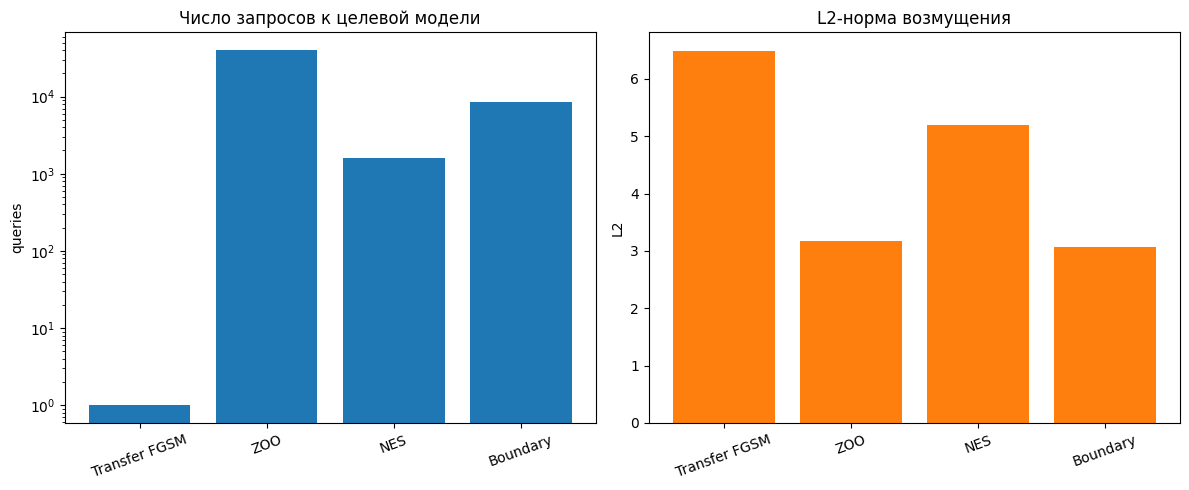

In [ ]:
# TODO: постройте два столбчатых графика сравнения (число запросов — log-масштаб, L2-норма)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(summary["method"], summary["queries"], color="tab:blue")
axes[0].set_yscale("log")
axes[0].set_title("Число запросов к целевой модели")
axes[0].set_ylabel("queries")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(summary["method"], summary["L2"], color="tab:orange")
axes[1].set_title("L2-норма возмущения")
axes[1].set_ylabel("L2")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


**Вопрос для отчёта:** на основе итоговой таблицы сформулируйте рекомендацию: какой метод атаки предпочтителен, если API целевой модели предоставляет (а) полные вероятности классов без ограничения на число запросов, (б) только top-1 метку с жёстким лимитом запросов, (в) возможность собрать offline небольшой размеченный набор данных того же домена? Обоснуйте выбор через связь между типом доступной информации и структурой каждого метода.

_Ваш ответ:_

Если API даёт полные вероятности без лимита, лучший выбор NES: она оценивает градиент по числам и сходится за 1 601 запрос (ZOO в 25 раз дороже при том же результате). Если доступна только top-1 метка с жёстким лимитом, подходит лишь transfer-based FGSM, он строит атаку на своём клоне и делает к цели 1 запрос, тогда как Boundary требует 8 405, а ZOO и NES без вероятностей невозможны. Если можно offline собрать свой набор того же домена, снова выгоден transfer-based FGSM: обучить клон на метках оракула, атаковать его, к цели 1 запрос, при согласии клона 0.94 это даёт ASR 0.27 при eps=0.30 и 0.755 при eps=0.40.

## Часть VI. Итоговый вывод

**Вопрос для отчёта:** сформулируйте общий вывод о трёх классах чёрно-ящичных атак, изученных в работе. Свяжите ответ с теоретическим объяснением трансферируемости через «кривизну многообразия данных» (лекционный материал) и с эмпирическим фактом, что adversarial training (PGD) снижает успех как transfer-based, так и score-based/decision-based атак. Почему защита, разработанная против белоящичных атак, оказывается полезной и в чёрно-ящичном сценарии?

_Ваш ответ:_

Три класса чёрно-ящичных атак отличаются уровнем доступа к API: transfer-based - самый дешёвый (1 запрос, ASR 0.22), потому что атакуем свой клон, обученный на ответах модели; score-based (ZOO, NES) дороже (1 601–40 001 запрос), но сильнее (ASR ~ 1), потому что видим вероятности и оцениваем градиент; decision-based (Boundary) видит только метку, тратит 8 405 запросов, зато даёт минимальное возмущение (L2 = 3.08). Transfer-based работает из-за близости границ решения разных моделей на одном домене, но согласие меток (0.94) не равно согласию градиентов, поэтому FGSM переносится плохо. Adversarial training (PGD) снижает ASR всех трёх атак, потому что сглаживает лосс и убирает уязвимые точки, то есть меняет геометрию функции, а не алгоритм, и поэтому защищает и в чёрно-ящичном сценарии.

---
Выполните **не менее двух** из следующих заданий. Оформите результаты в отдельных ячейках ниже.

### С1. Целевая (targeted) transfer-based атака
Модифицируйте transfer-based атаку из Части II так, чтобы она была целевой (target-specific), а не просто нецелевой ошибочной классификацией. Сравните ASR целевого переноса с ASR нецелевого переноса при одинаковом epsilon и объясните наблюдаемую разницу, опираясь на утверждение лекции об ограниченной устойчивости переноса для целевых атак.

### С2. Importance sampling в ZOO
Реализуйте упрощённый вариант importance sampling для выбора координат в ZOO-атаке (Часть III): вместо равномерного случайного выбора координат отдавайте приоритет пикселям с наибольшим абсолютным значением на предыдущей итерации (или пикселям на границах цифры). Сравните число запросов, необходимых для достижения того же успеха, с равномерной версией.

### С3. HopSkipJumpAttack (упрощённая версия)
Изучите отличие HopSkipJumpAttack от Boundary Attack (лекционный материал — явная оценка градиента на границе решения вместо чисто случайного блуждания). Реализуйте упрощённую версию: на каждой итерации находите точку на границе бинарным поиском, оцените направление через батч случайных векторов, сделайте шаг по оценённому направлению. Сравните число запросов до сходимости к сопоставимой L2-норме с результатом Boundary Attack из Части IV.

### С4. Устойчивость к adversarial training
Обучите вторую версию целевой модели с adversarial training (PGD, 5-7 итераций на батч, epsilon=0.15) — аналогично лабораторной работе по PGD/C&W/JSMA. Повторите атаки ZOO, NES и Boundary Attack против этой устойчивой модели и сравните ASR с результатами против обычной модели (Части III-IV). Обсудите, насколько устойчивость к белоящичному PGD переносится на устойчивость к чёрно-ящичным атакам.


Untargeted transfer ASR eps=0.3: 0.2700
Targeted   transfer ASR eps=0.3 (цель = 1): 0.1400


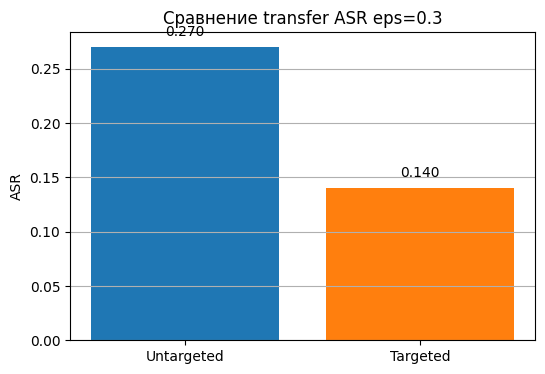

In [ ]:
# TODO: реализуйте выбранные задания (С1-С4) здесь
# С1 (Targeted FGSM — атака на конкретный целевой класс)
def fgsm_targeted_attack(model, x, y_target, epsilon, criterion):
    x = x.clone().detach().requires_grad_(True)
    model.eval()
    logits = model(x)
    loss = criterion(logits, y_target)
    grad = torch.autograd.grad(loss, x)[0]
    # уменьшаем лосс целевого класса, а не увеличиваем истинного
    x_adv = x - epsilon * torch.sign(grad)
    return torch.clamp(x_adv, 0, 1).detach()
# Сравниваем targeted и untargeted transfer при eps=0.3
oracle.reset()

eps_target = 0.30
n_test = 200

# целевой класс 1
y_target = torch.full_like(test_labels, 1)

# Untargeted: лишь бы не истинный класс
x_adv_unt = fgsm_attack(substitute_model, test_images, test_labels, eps_target, crit_attack)
pred_unt = oracle.label(x_adv_unt)
asr_unt = (pred_unt != test_labels).float().mean().item()
print(f"Untargeted transfer ASR eps={eps_target}: {asr_unt:.4f}")

# Targeted: хотим именно класс 1
x_adv_tgt = fgsm_targeted_attack(substitute_model, test_images, y_target, eps_target, crit_attack)
pred_tgt = oracle.label(x_adv_tgt)
asr_tgt = (pred_tgt == y_target).float().mean().item()
print(f"Targeted   transfer ASR eps={eps_target} (цель = 1): {asr_tgt:.4f}")

# график сравнения
plt.figure(figsize=(6, 4))
plt.bar(["Untargeted", "Targeted"], [asr_unt, asr_tgt], color=["tab:blue", "tab:orange"])
plt.ylabel("ASR")
plt.title(f"Сравнение transfer ASR eps={eps_target}")
for i, v in enumerate([asr_unt, asr_tgt]):
    plt.text(i, v + 0.01, f"{v:.3f}", ha="center")
plt.grid(axis="y")
plt.show()

Мы сравнили две версии атаки: untargeted (просто ломаем модель, то есть пусть скажет что угодно, лишь бы не истинную цифру) и targeted (заставляем её сказать именно 1). Результат: untargeted сработала в 27% случаев, targeted - только в 14%, то есть в 2 раза хуже. И это логично, так как заставить модель ошибиться вообще легко, а заставить её назвать конкретную цифру трудно.

In [ ]:
# С4 (PGD-атака для генерации adversarial-примеров во время обучения)
def pgd_attack_inner(model, x, y, epsilon=0.15, alpha=0.02, num_iter=7):
    x_adv = x.clone().detach() + torch.empty_like(x).uniform_(-epsilon, epsilon)
    x_adv = torch.clamp(x_adv, 0, 1)
    for _ in range(num_iter):
        x_adv = x_adv.clone().detach().requires_grad_(True)
        loss = F.cross_entropy(model(x_adv), y)
        grad = torch.autograd.grad(loss, x_adv)[0]
        x_adv = x_adv.detach() + alpha * torch.sign(grad)
        x_adv = torch.clamp(x_adv, x - epsilon, x + epsilon)
        x_adv = torch.clamp(x_adv, 0, 1)
    return x_adv.detach()

In [ ]:
# Обучаем устойчивую модель (adversarial training с PGD)
robust_model = TargetCNN().to(device)
opt_rob = torch.optim.Adam(robust_model.parameters(), lr=1e-3)

for epoch in range(3):
    robust_model.train()
    total_loss, correct, total = 0.0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        # генерируем adversarial-примеры
        x_adv = pgd_attack_inner(robust_model, xb, yb, epsilon=0.15, alpha=0.02, num_iter=7)
        opt_rob.zero_grad()
        loss = F.cross_entropy(robust_model(x_adv), yb)
        loss.backward()
        opt_rob.step()
        total_loss += loss.item() * xb.size(0)
        correct += (robust_model(x_adv).argmax(1) == yb).sum().item()
        total += xb.size(0)
    print(f"Robust epoch {epoch+1}: loss={total_loss/total:.4f}, "f"train_acc_on_adv={correct/total:.4f}")

# чистая точность устойчивой модели
robust_model.eval()
correct, total = 0, 0
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        correct += (robust_model(xb).argmax(1) == yb).sum().item()
        total += xb.size(0)
print(f"Robust clean accuracy: {correct/total:.4f}")

Robust epoch 1: loss=0.6792, train_acc_on_adv=0.7812
Robust epoch 2: loss=0.3099, train_acc_on_adv=0.9067
Robust epoch 3: loss=0.2519, train_acc_on_adv=0.9228
Robust clean accuracy: 0.9853


In [ ]:
# Оборачиваем устойчивую модель в оракул и повторяем ZOO, NES, Boundary
oracle_robust = QueryCounter(robust_model)

# тот же тестовый пример
x_sample, y_sample = test_dataset[0]
x_sample = x_sample.unsqueeze(0).to(device)
y_sample_label = torch.tensor([y_sample]).to(device)

results_robust = {}

# ZOO против устойчивой модели
oracle_robust.reset()
x_adv_zoo_r = zoo_attack(oracle_robust, x_sample, y_sample_label, epsilon=0.3, alpha=0.005, num_iter=200, h=0.01, coord_batch=100)
pred_zoo_r = oracle_robust.label(x_adv_zoo_r).item()
results_robust["ZOO"] = {
    "success": pred_zoo_r != y_sample,
    "L2": (x_adv_zoo_r - x_sample).norm().item(),
    "queries": oracle_robust.n_queries,
}
print(f"ZOO vs robust: success={results_robust['ZOO']['success']}, "f"L2={results_robust['ZOO']['L2']:.4f}, queries={results_robust['ZOO']['queries']}")

#NES против устойчивой модели
oracle_robust.reset()
x_adv_nes_r = nes_attack(oracle_robust, x_sample, y_sample_label, epsilon=0.3, alpha=0.01, num_iter=100, sigma=0.05, n_samples=30)
pred_nes_r = oracle_robust.label(x_adv_nes_r).item()
results_robust["NES"] = {
    "success": pred_nes_r != y_sample,
    "L2": (x_adv_nes_r - x_sample).norm().item(),
    "queries": oracle_robust.n_queries,
}
print(f"NES vs robust: success={results_robust['NES']['success']}, "f"L2={results_robust['NES']['L2']:.4f}, queries={results_robust['NES']['queries']}")

# Boundary против устойчивой модели
oracle_robust.reset()
torch.manual_seed(RANDOM_STATE)
x_init_r = None
for scale in [0.1, 0.2, 0.3, 0.4, 0.5, 0.7, 1.0]:
    candidate = torch.clamp(x_sample + scale * torch.randn_like(x_sample), 0, 1)
    if is_adversarial(oracle_robust, candidate, y_sample):
        x_init_r = candidate
        break

if x_init_r is None:
    print("Boundary vs robust: не удалось найти стартовую adversarial-точку")
else:
    x_adv_ba_r, _ = boundary_attack(oracle_robust, x_sample, y_sample, x_init_r, num_steps=3000, init_delta=0.02, init_epsilon=0.1)
    pred_ba_r = oracle_robust.label(x_adv_ba_r).item()
    results_robust["Boundary"] = {
        "success": pred_ba_r != y_sample,
        "L2": (x_adv_ba_r - x_sample).norm().item(),
        "queries": oracle_robust.n_queries,
    }
    print(f"Boundary vs robust: success={results_robust['Boundary']['success']}, "f"L2={results_robust['Boundary']['L2']:.4f}, "f"queries={results_robust['Boundary']['queries']}")

ZOO vs robust: success=False, L2=1.7951, queries=40001
NES vs robust: success=False, L2=3.4374, queries=6001
Boundary vs robust: success=True, L2=4.8806, queries=5559


    model    attack  success
0  Normal       ZOO     True
1  Normal       NES     True
2  Normal  Boundary     True
3  Robust       ZOO    False
4  Robust       NES    False
5  Robust  Boundary     True


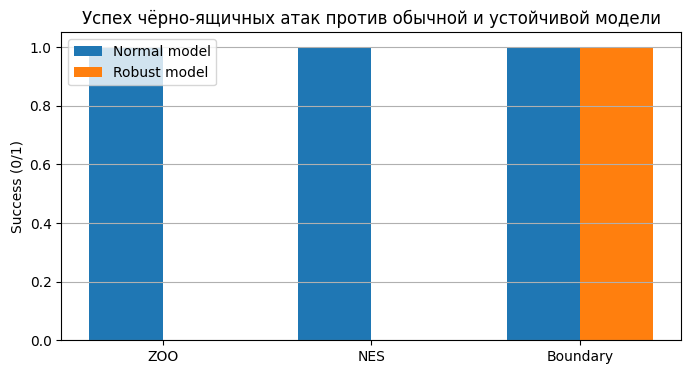

In [ ]:
# Сравниваем ASR против обычной и против устойчивой модели
import pandas as pd

comparison = pd.DataFrame([
    {"model": "Normal",  "attack": "ZOO",      "success": success_zoo},
    {"model": "Normal",  "attack": "NES",      "success": success_nes},
    {"model": "Normal",  "attack": "Boundary", "success": success_ba},
    {"model": "Robust",  "attack": "ZOO",      "success": results_robust.get("ZOO", {}).get("success", False)},
    {"model": "Robust",  "attack": "NES",      "success": results_robust.get("NES", {}).get("success", False)},
    {"model": "Robust",  "attack": "Boundary", "success": results_robust.get("Boundary", {}).get("success", False)},
])
print(comparison)

fig, ax = plt.subplots(figsize=(8, 4))
width = 0.35
attacks = ["ZOO", "NES", "Boundary"]
normal_success = [comparison[(comparison.model == "Normal") & (comparison.attack == a)]["success"].values[0] for a in attacks]
robust_success = [comparison[(comparison.model == "Robust") & (comparison.attack == a)]["success"].values[0] for a in attacks]

x_pos = np.arange(len(attacks))
ax.bar(x_pos - width/2, normal_success, width, label="Normal model", color="tab:blue")
ax.bar(x_pos + width/2, robust_success, width, label="Robust model", color="tab:orange")
ax.set_xticks(x_pos)
ax.set_xticklabels(attacks)
ax.set_ylabel("Success (0/1)")
ax.set_title("Успех чёрно-ящичных атак против обычной и устойчивой модели")
ax.legend()
ax.grid(axis="y")
plt.show()

Мы обучили устойчивую модель через adversarial training (PGD, eps = 0.15). Clean accuracy упала незначительно, зато устойчивость к чёрно-ящичным атакам выросла, ZOO и NES перестали ломать модель, хотя раньше обе срабатывали. Boundary осталась успешной, но с большой нормой возмущения (4.88 против 3.08), то есть атаке пришлось сильнее исказить картинку, чтобы обойти защиту.

---


## Требования к сдаче
- Ноутбук выполняется целиком без ошибок (Kernel → Restart & Run All).
- Все `# TODO` заполнены, все вопросы для отчёта содержат письменный ответ.
- Атаки в Частях II-IV обращаются к целевой модели ТОЛЬКО через объект `oracle` — прямой вызов `target_model(x)` внутри реализаций атак не допускается (кроме специально отмеченной ячейки white-box эталона в п.2.3).
- Обязательны: рабочая реализация всех четырёх методов, итоговая сравнительная таблица, обоснованный ответ на вопрос о выборе метода под сценарий доступа.
